In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [61]:
df = pd.read_csv('data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [62]:
print("Shape:", df.shape)
print("\n")
print(df.info())
print("\n")
print(df.describe())

Shape: (891, 12)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     

In [63]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [64]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11032\20540041.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set1')


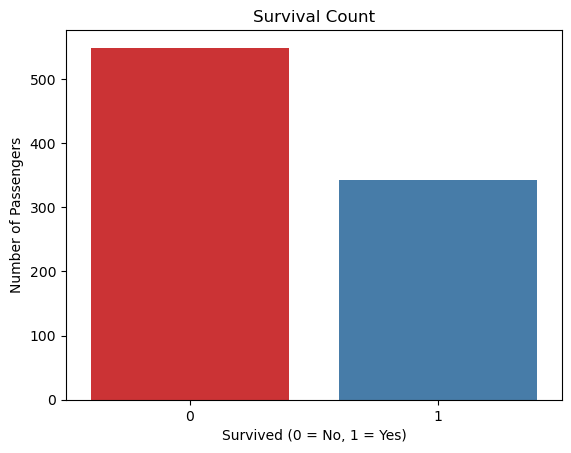

In [65]:
sns.countplot(x='Survived', data=df, palette='Set1')

plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.show()

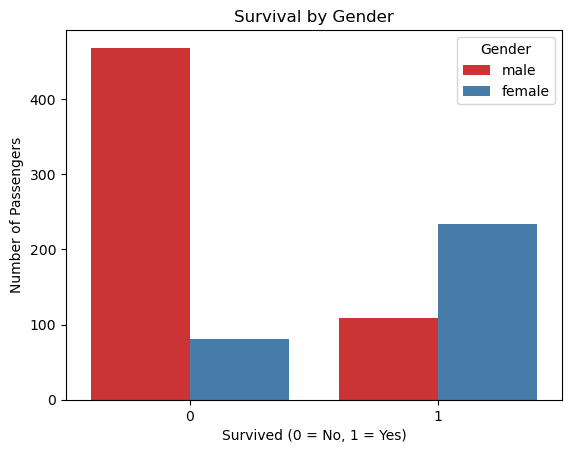

In [66]:
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set1')

plt.title('Survival by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.legend(title='Gender')

plt.show()

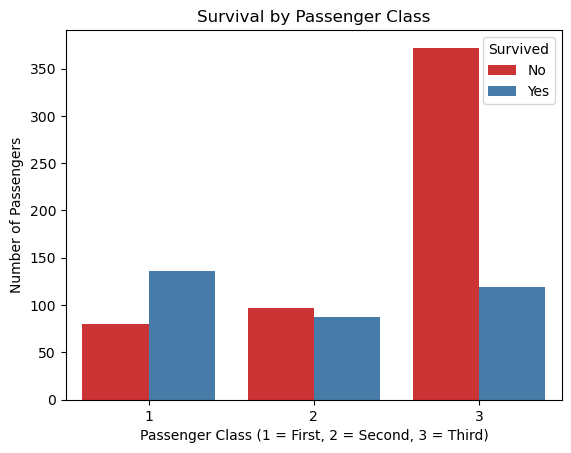

In [67]:
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set1')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])

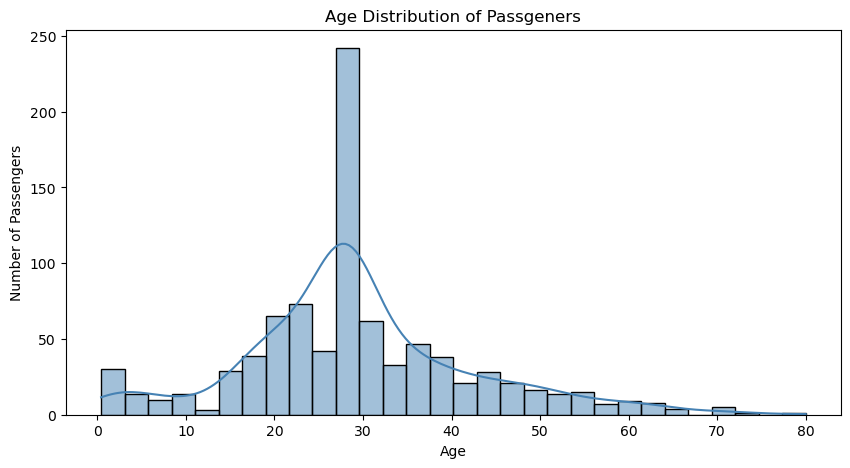

In [68]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')

plt.title('Age Distribution of Passgeners')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

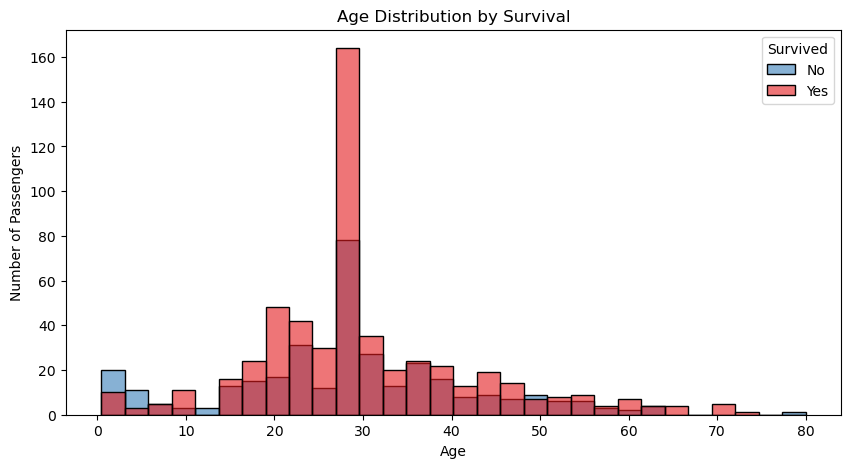

In [69]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=False, alpha=0.6, palette='Set1')

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()

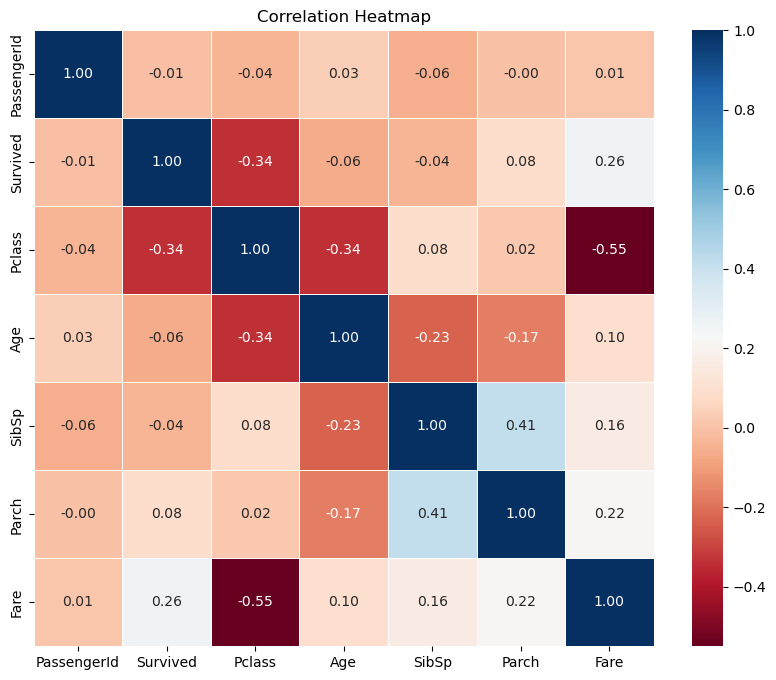

In [70]:
plt.figure(figsize=(10, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu', linewidths=.5)

plt.title('Correlation Heatmap')

plt.show()

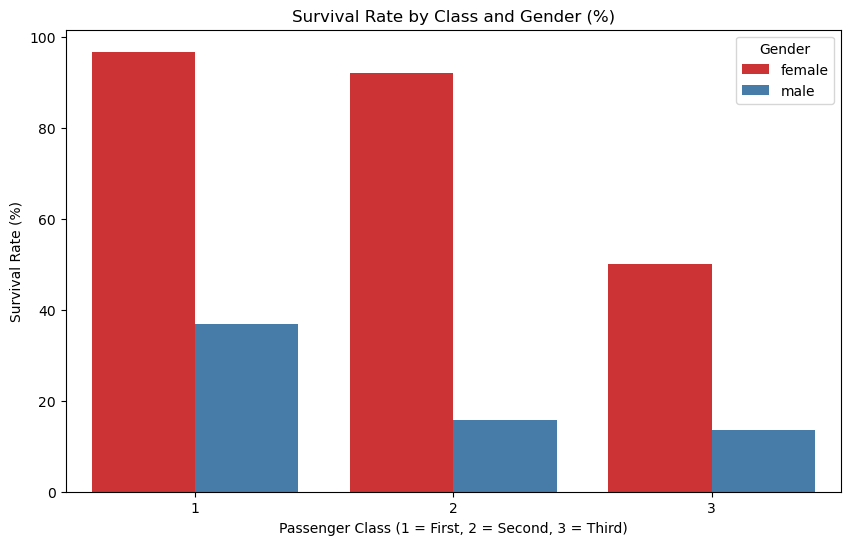

In [71]:
plt.figure(figsize=(10, 6))

survival_rate = df.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
survival_rate = survival_rate.reset_index()

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=survival_rate, palette='Set1')

plt.title('Survival Rate by Class and Gender (%)')
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Survival Rate (%)')
plt.legend(title = 'Gender')

plt.show()

In [ ]:
print("=== Titanic Dataset - Key Findings ===")
print()

total=len(df)
survived = df['Survived'].sum()
survival_rate = (survived / total) * 100
print(f"Total Passengers: {total}")
print(f"Total Survivors: {survived}")
print(f"Overall Survival Rate: {survival_rate:.1f}%")
print()

print("--- Survival Rate by Gender ---")
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
for gender, rate in gender_survival.items():
    print(f"   {gender.capitalize()}: {rate:.1f}%")
print()

print("--- Survival Rate by Passenger Class ---")
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
for pclass, rate in class_survival.items():
    print(f" Class {pclass}: {rate:.1f}%")
print()

print("--- Age Statistics ---")
print(f"Average Age: {df['Age'].mean():.1f}")
print(f"Youngest Passenger: {df['Age'].min():.1f}")
print(f"Oldest Passenger: {df['Age'].max():.1f}")


=== Titanic Dataset - Key Findings ===

Total Passengers: 891
Total Survivors: 342
Overall Survival Rate: 38.4%

--- Survival Rate by Gender ---
   Female: 74.2%
   Male: 18.9%

--- Survival Rate by Passenger Class ---
 Class 1: 63.0%
 Class 2: 47.3%
 Class 3: 24.2%

--- Age Statistics ---
Average Age: 29.4
Youngest Passenger: 0.4
Oldest Passenger: 80.0
